# LSTM Sequence-to-Sequence Autoencoder

Sequence-to-Sequence (Seq2Seq) Autoencoders compress variable-length sequence steps into fixed-size latent representation bottleneck vectors using recurrent neural networks (like LSTMs). Decoders then reconstruct the original sequences back step-by-step from the latent bottleneck. This notebook implements an LSTM Seq2Seq Autoencoder in PyTorch to reconstruct noisy time-series signals and visualizes reconstructed curves in Matplotlib.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Generate synthetic time-series curves (600 samples, sequence length = 20 steps, feature dim = 1)
np.random.seed(260)
n_samples = 600
seq_len = 20

t = np.linspace(0, 4*np.pi, seq_len)
base_wave = np.sin(t)

X_data = []
for _ in range(n_samples):
    # Random amplitude and phase shifts + Gaussian noise
    amp = np.random.uniform(0.5, 1.5)
    phase = np.random.uniform(-0.5, 0.5)
    noise = np.random.normal(0, 0.1, seq_len)
    
    signal = amp * np.sin(t + phase) + noise
    X_data.append(signal)

X = np.array(X_data) # [600, 20]
# Add channel dimension: [600, 20, 1]
X = np.expand_dims(X, axis=2)

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

print("Train Sequences shape:", X_train_t.shape)
print("Test Sequences shape: ", X_test_t.shape)



Train Sequences shape: torch.Size([480, 20, 1])
Test Sequences shape:  torch.Size([120, 20, 1])


## LSTM Seq2Seq Autoencoder Architecture

We implement the encoder-decoder model in PyTorch:
- **Encoder**: Processes inputs, extracting the final step hidden vector as the bottleneck (latent size=16).
- **Decoder**: Repeats the bottleneck vector `seq_len` times and decodes it back to reconstructed values.



In [2]:
class EncoderLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16):
        super(EncoderLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        
    def forward(self, x):
        # outputs shape: [batch, seq_len, hidden_dim]
        # h_n, c_n shape: [1, batch, hidden_dim]
        outputs, (h_n, c_n) = self.lstm(x)
        # Return final step hidden state as latent vector
        return h_n.squeeze(0)

class DecoderLSTM(nn.Module):
    def __init__(self, latent_dim=16, output_dim=1):
        super(DecoderLSTM, self).__init__()
        self.lstm = nn.LSTM(latent_dim, latent_dim, batch_first=True)
        self.fc = nn.Linear(latent_dim, output_dim)
        
    def forward(self, z, steps=20):
        # Repeat latent vector z: shape [batch, steps, latent_dim]
        repeated_z = z.unsqueeze(1).repeat(1, steps, 1)
        outputs, _ = self.lstm(repeated_z)
        recon = self.fc(outputs)
        return recon

class Seq2SeqAutoencoder(nn.Module):
    def __init__(self, input_dim=1, latent_dim=16):
        super(Seq2SeqAutoencoder, self).__init__()
        self.encoder = EncoderLSTM(input_dim, latent_dim)
        self.decoder = DecoderLSTM(latent_dim, input_dim)
        
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z, steps=x.size(1))
        return recon

model = Seq2SeqAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.008)



## Autoencoder Training Loop

We train the recurrent autoencoder for 120 epochs.



In [3]:
epochs = 120
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    reconstructed = model(X_train_t)
    loss = criterion(reconstructed, X_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if epoch % 30 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | Reconstruction MSE Loss: {loss.item():.4f}")

# Calculate test loss
model.eval()
with torch.no_grad():
    test_recon = model(X_test_t)
    test_loss = criterion(test_recon, X_test_t).item()
print(f"\nFinal Test Reconstruction MSE: {test_loss:.4f}")



Epoch  30/120 | Reconstruction MSE Loss: 0.4610
Epoch  60/120 | Reconstruction MSE Loss: 0.1538
Epoch  90/120 | Reconstruction MSE Loss: 0.0723
Epoch 120/120 | Reconstruction MSE Loss: 0.0567

Final Test Reconstruction MSE: 0.0510


## Reconstructed Signal Waveform Plots

Using Matplotlib, we trace a sample test signal sequence against its reconstructed counterpart to verify compression alignment.



<cell>:12: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



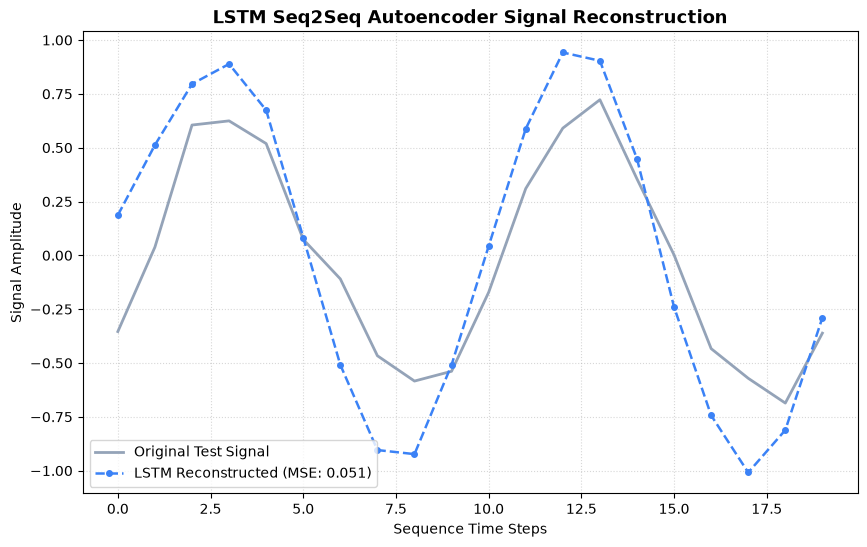

In [4]:
plt.figure(figsize=(10, 6))

sample_idx = 0
plt.plot(X_test[sample_idx, :, 0], color='#94A3B8', label='Original Test Signal', linewidth=2.0)
plt.plot(test_recon[sample_idx, :, 0].numpy(), color='#3B82F6', linestyle='--', marker='o', markersize=4, label=f'LSTM Reconstructed (MSE: {test_loss:.3f})', linewidth=1.8)

plt.title('LSTM Seq2Seq Autoencoder Signal Reconstruction', fontsize=13, fontweight='bold')
plt.xlabel('Sequence Time Steps')
plt.ylabel('Signal Amplitude')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
